In [323]:
%pip install matplotlib numpy pandas scikit-learn seaborn cloudpickle

Note: you may need to restart the kernel to use updated packages.


## End-To-End Machile Learning

### Tarefa

Utilizar o Censo da California para criar um modelo de previsão da mediana do preço da casa em qualquer lugar do Estado


### Entendendo o problema e Objetivo de Mercado (Business)

Como essa mediana do preço de uma casa pode ajudar a empresa ? oq a empresa espera desse modelo ? que mudanças vai trazer ? vamos supor que esse modelo ira gerar uma feature (predição da mediana) que será futuramente usada em outro modelo em conjunto com outras features para decidir ou não um investimento.... como queremos prever um valor continuo isso é uma tarefa supervisionada de regressão univariada (um target apenas) multipla (várias features), como nenhum dado esta sendo digerido e a quantidade de dados é pouca podemos usar offline learning sem problemas.

Agora precisamos decidir a função de perda (medida de performace)... como temos os rotulos podemos usar uma métrica de distancia vetorial como RSME e MAE. Ambas calculam a distancia de cada predição para seu valor rotulado mas RSME (root mean squared error) eleva os erros ao quadrado dando mais peso para erros grandes porém sendo mais afetada por outliers uma vez que elevamos ao quadrado. Em situações com outliers seria mais interessante usar MAE (mean absolute error) que faz a media do absoluto dos erros (ambos são norma 2 e 1 respectivamente de dois vetores). No nosso caso não temos muitos outliers e portanto não é necessário usar MAE.

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$


$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

### Pegando os dados:

Geralmente quando vamos pegar os dados nos temos que ter credenciais de bancos relacionais ou não relacionais e fazemos a coleta através de requisições nesses bancos. Entretanto aqui vamos pegar um dado comprimido do github e que vamos baixar e descomprimir automaticamente... é importante que esse processo seja automatizado e dessa forma pois se baixarmos os dados brutos (se eles couberem na maquina) nossos dados baixados poderiam ficar desatualizados. Também é util esse script se voce precisar baixar os dados em várias maquinas.


In [324]:
import pandas as pd
from pathlib import Path # objeto que representa uma rota de arquivo
import tarfile
import urllib

def load_data():
    data_tar_path = Path("datasets/housing.tgz")
    if not data_tar_path.is_file():
        data_dir = data_tar_path.parent 
        data_dir.mkdir(exist_ok=True) # cria o diretório pai se ele não existir
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, data_tar_path) # baixa o arquivo do url e salva no caminho data_tar_path

    with tarfile.open(data_tar_path) as housing_tgz:
        housing_tgz.extractall(path=data_tar_path.parent, filter='data') # extrai 

    return pd.read_csv(data_tar_path.parent / "housing" / "housing.csv")

housing = load_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Explorando um pouco os dados

In [325]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Podemos ver que total_bedrooms tem alguns dados faltantes... e que ocean_proximity é provavelmente uma atributo categórico entao vamos ver a frequencia:

In [326]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [327]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


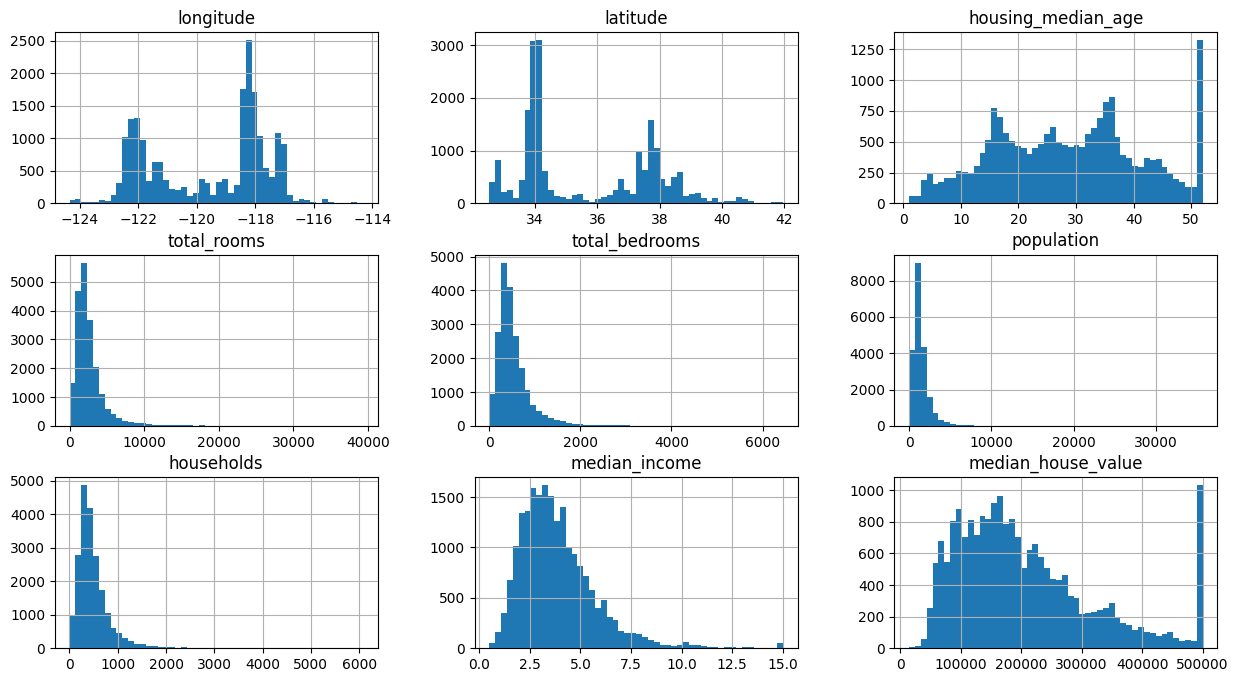

In [328]:
import matplotlib.pyplot as plt
# disttribuição dos dados
housing.hist(bins=50, figsize=(15,8))
plt.show()


Podemos reparar que alguma distribuicoes estao com assimetria a direita e cauda pesada (valores extremos bem frequentes)... podemos ver que total_rooms, total_bedrooms, population, households e median_income (nem tanto) sao os mais assimétricos. Depois precisáremos talvez aplicar transformacao log para deixar mais proximo de uma normal... Além disso podemos ver que o nosso target (median_house_value) e house_median_age estao limitados a 500000 e 50 respectivamente e isso provavelmente aconteceu por um erro ou por alguma normalizacao na coleta... idealmente temos duas opcoes: 1. Coletar os dados corretos desse enderecos em que os dados foram cortados 2. retirar dos dados essas linhas pois isso irá fazer o modelo ser erroneamente punido por prever valores maiores que 500000... subestimando o valor real. Além disso temos diferentes escalas que podem ser normalizadas.


### Criando conjunto de teste

Precisamos criar um conjunto de teste e nao olhar mais para ele nem estudar ele pois isso pode levar a um vies em que identificamos um padrao e usamos para escolher modelo ou tomar decisoes... esse vies é chamado de data snooping bias (vies de bisbilhotagem). Data leakage é quando informações do target vazam para o treino indiretamente... um exemplo disso é prever um target usando uma variavel que é gerada depois do target acontecer ou padronizar usando media/desvio de amostra toda dando informação...

In [329]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing ,test_size=0.2, random_state=42)
validation_set, test_set = train_test_split(test_set ,test_size=0.6, random_state=42)

len(train_set), len(validation_set), len(test_set)


(16512, 1651, 2477)

Essa divisao é util mas até agora estamos criando nossos datasets de treino e teste usando amostragem aleatória (todos as linhas tem a mesma probabilidade de ser pega)... isso é ok se seu dataset é grande suficientemente e o erro amostral é baixo (ou se o numero de features é alto). Caso contrário isso pode gerar vies amostral ... imagine uma populacao que 48% sao homens e 52% mulheres, se fizermos uma amostragem aleatória podemos acabar por acaso com 40% mulheres e 60% homens e isso nao representa a populacao. Por isso, usamos amostragem estratificada que considera grupos da populacao e tenta manter a amostra com a mesma proporcao dos grupos. Imagine no nosso caso que uma variavel muito importe para nossa predicao é median_income, entao precisamos amostrar nossos conjuntos de teste e treino de forma a manter as proporcoes da populacao e supondo que nossa amostra é representativa da populacao entao nos temos que seguir a proporcao do dataset inteiro. Como median_income é uma variavel continua nao conseguimos estratificar entao precisamos transformar em intervalos e cada um desses intervalos tem que ter numeros suficientes de exemplos para que nao tenha vies para algum strata entao nao podemos ter muitas classes/stratas/grupos... 

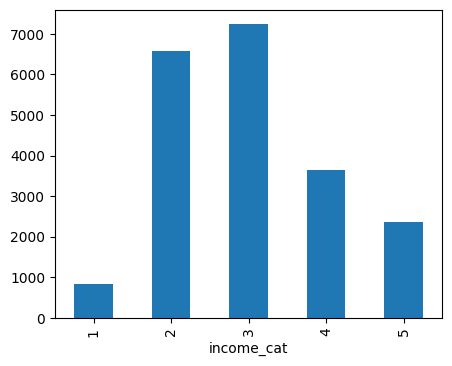

In [330]:
housing['income_cat'] = pd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., float('inf')], labels=[1, 2, 3, 4, 5])
# bins sao os limites das categorias, labels são os rótulos para cada categoria.

values_counts = housing['income_cat'].value_counts()
values_counts.sort_index().plot.bar(figsize=(5, 4))

plt.show()

Agora que dividimos em categorias podemos fazer a divisao estratificada e manter a mesma proporsao...

In [ ]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, random_state=42, stratify=housing['income_cat'])
no_strat_train_set, no_strat_test_set = train_test_split(housing, test_size=0.2, random_state=42)

original_distribution = housing['income_cat'].value_counts() / len(housing)

strat_distribution = strat_test_set['income_cat'].value_counts() / len(strat_test_set)

no_strat_distribution = no_strat_test_set['income_cat'].value_counts() / len(no_strat_test_set)

comparison = pd.DataFrame({
    'Original': original_distribution,
    'Stratified': strat_distribution,
    'No Stratified': no_strat_distribution
})

comparison


,Original,Stratified,No Stratified
income_cat,,,
3,0.350581,0.350533,0.345203
2,0.318847,0.318798,0.307413
4,0.176308,0.176357,0.184109
5,0.114438,0.114341,0.120882
1,0.039826,0.039971,0.042393


### Explorando os dados de treino

Podemos explorar varias coisas nos dados... uma dedlas é geograficamente como os pontos estão distribuidos

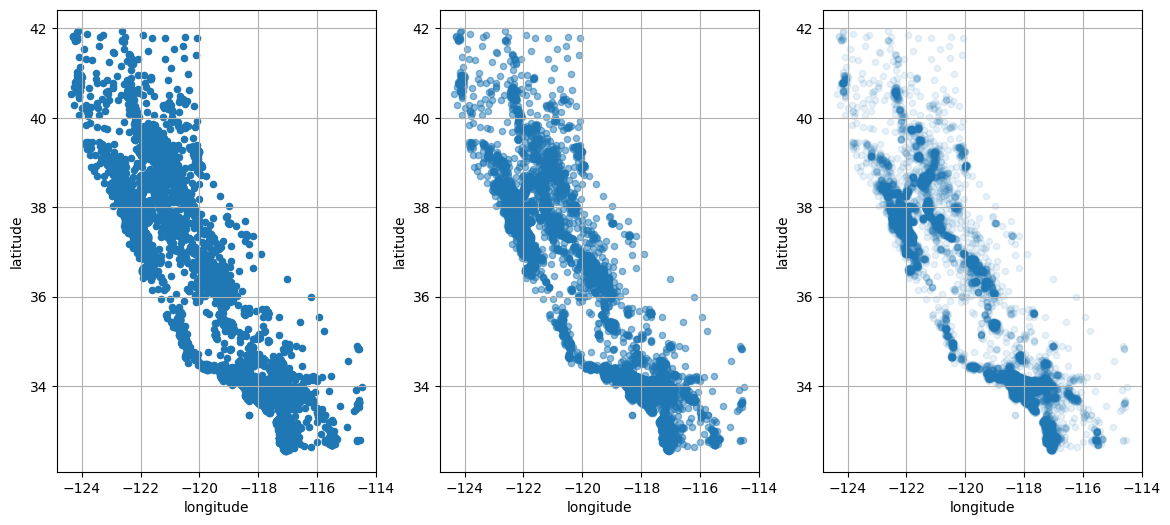

In [332]:
housing = strat_train_set.drop('income_cat', axis=1).copy()

subplots = plt.subplots(1,3,figsize=(14, 6)) # plots com alfas diferentes

# alpha é a transparência dos pontos, quanto menor o valor, mais transparente fica o ponto
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True, alpha=1, ax=subplots[1][0]) 
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True, alpha=0.5, ax=subplots[1][1])
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True, alpha=0.1, ax=subplots[1][2])

plt.show()

Podemos visualizar padrões dos dados usando parâmetros de cor 

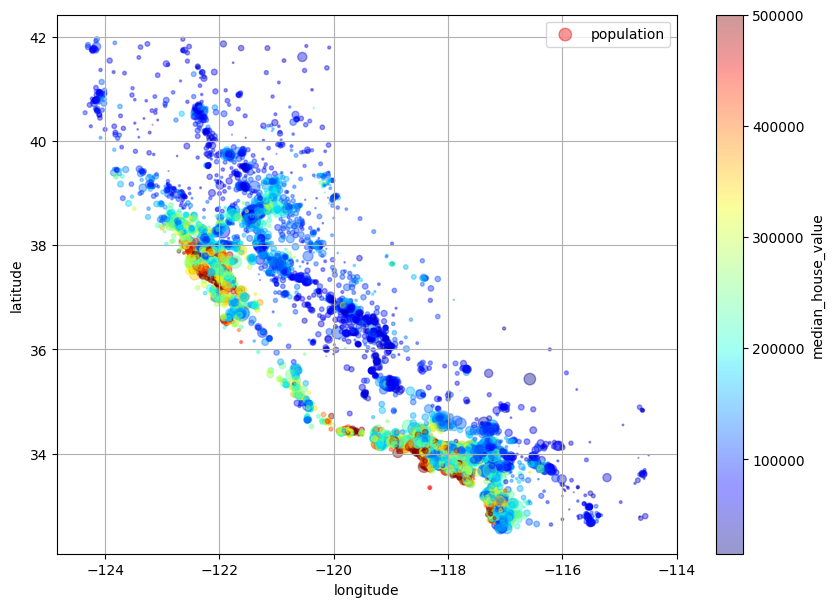

In [333]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True, alpha=0.4, s=housing['population']/100, label='population', figsize=(10,7), c='median_house_value', cmap=plt.get_cmap('jet'))
plt.legend()
plt.show()


# s controla o tamanho dos pontos seguindo alguma regra, nesse caso, o tamanho dos pontos é proporcional à população dividida por 100. 
# c controla a cor dos pontos, nesse caso, a cor é determinada pelo valor da mediana das casas. 
# O cmap é o mapa de cores usado para representar os valores da mediana das casas, nesse caso, o mapa de cores 'jet' é usado. 

Podemos analisar as correlações lineares dos dados em relação a variavel target para ver variaveis promissoras para predição e realizar a feature selection

In [334]:
corr_matrix = housing.corr(numeric_only=True)

corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

Ou uma matriz de scatterplots que também ajuda a identificar correlações não lineares.

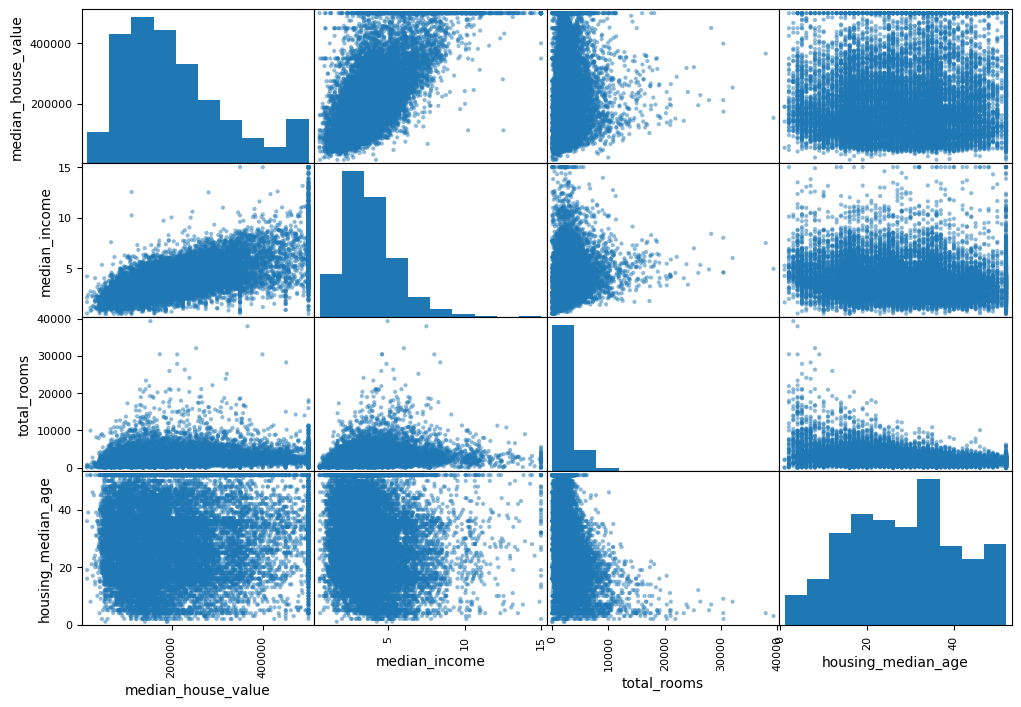

In [335]:
from pandas.plotting import scatter_matrix

attributes = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

Podemos testar combinações de features (feature extraction) para tentar encontrar novas features boas... como por exemplo o numero de quartos em relação ao numero total de comodos do distrito, numero de quartos em relação ao numero total de casas e numero de pessoas por casa...

In [336]:
housing['population per household'] = housing['population'] / housing['households']
housing['rooms per household'] = housing['total_rooms'] / housing['households']
housing['bedrooms per room'] = housing['total_bedrooms'] / housing['total_rooms']

housing.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False)

housing = housing.drop(['population per household', 'rooms per household', 'bedrooms per room'], axis=1)

Da para ver que duas das variaveis criadas tem um correlação maior com target que elas sozinhas... sendo mais uteis assim. Quando estiver criando novas variaveis com as existentes é importante ter cuidado para gerar features com correlação muito alta entre si (colinearidade) pois isso é um problema pois quebra a suposição delas serem independentes e também prejudica a interpretabilidade uma vez que não sabemos qual das duas esta causando uma melhoria...

### Preparando os dados para os modelos

Antes de mandar os dados para o modelo é necessário tratar os dados para que o modelo aprenda com algo bom

Dados Faltantes: temos 3 opções para lidar com dados faltantes em uma coluna...
- Excluir as linhas com os nulos (pouco interessante se voce tem poucos dados)
- Excluir a coluna inteira (feature)
- Usar algum método de imputação de dados...

In [337]:
import numpy as np

housing_labels = housing['median_house_value'].copy()
housing = housing.drop('median_house_value', axis=1)

housing_num = housing.select_dtypes(include=[np.number])

# as 3 coisas podem ser feitas com pandas:

# excluir linhas com valores faltantes
#  -> housing_exemplo.dropna(subset=['total_bedrooms'], inplace=True)
# preencher os valores faltantes com algum valor, como a média, mediana ou moda da coluna.
# -> housing_exemplo['total_bedrooms'].fillna(housing_exemplo['total_bedrooms'].mean(), inplace=True)
# excluir a coluna com valores faltantes
# -> housing_exemplo.drop(columns=['total_bedrooms'], inplace=True)


# scikit-learn tem um imputer que pode ser usado para preencher os valores faltantes com a média, mediana ou moda da coluna. 
# ou algum método mais avançado, como KNN ou regressão.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer

imputer_knn = KNNImputer(n_neighbors=5)
imputer_knn.fit(housing_num)
imputed_housing_num = imputer_knn.transform(housing_num) # retorna um array numpy com os valores preenchidos

housing_tr = pd.DataFrame(imputed_housing_num, columns=housing_num.columns, index=housing_num.index) # converte o array numpy de volta para um DataFrame do pandas

housing_tr.info()
housing_tr.head()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292


Simple imputer usa métricas simples para imputar como por exemplo a média, mediana e moda da coluna... KNN usa a media dos k vizinhos mais proximos do ponto no espaço dimensional das features (todas features) e Iterative usa varias regressões para tentar prever o valor faltante... É mais interessante usar o Imputer em producao pois ele armazena as métricas tiradas no conjunto de treino e usa as mesmas métricas no conjunto de validacao e teste. Evitando data leakage e garantindo que o processamento seja identico...

Lindando com dados categóricos:

In [338]:
housing_cat = housing.select_dtypes(exclude=[np.number])

housing_cat.value_counts()

ocean_proximity
<1H OCEAN          7274
INLAND             5301
NEAR OCEAN         2089
NEAR BAY           1846
ISLAND                2
Name: count, dtype: int64

Para essas colunas serem usadas em algoritmos elas precisam ser convertidas em numeros... podemos converter cada categoria em valores 0,1,2,3,4 com um encoding Ordinal... mas isso ira que o algoritmo exergue classes com numeros proximos como classes muito proximas... se variavel é qualitativa e ordinal isso faz sentido pois ruim realmente esta mais proximo de medio do que de perfeito... agora caso ela não seja ordinal é melhor utilizar métodos que transformar cada classe em uma coluna binária e isso é chamado de OnehotEncoding... podemos fazer isso tanto usando a função get_dummies() do python e o Encoder do Scikit... Além disso, se temos muitas classes o onehot ira gerar muitas colunas novas levando a maldição da dimensionalidade... nesses casos a melhor forma é ou trocar a feature categorica por uma continua que represente a mesma coisa ou usar representações densas (embeddings).

In [339]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(housing_cat)
housing_cat_encoded = ordinal_encoder.transform(housing_cat)
print(housing_cat_encoded[:5])
print(ordinal_encoder.categories_)

# aqui cada classe virou um inteiro de 0 a n-1, onde n é o número de classes.

onehot_encoder = OneHotEncoder(handle_unknown='ignore')
onehot_encoder.fit(housing_cat)
housing_cat_onehot = onehot_encoder.transform(housing_cat) 
print(housing_cat_onehot.toarray()[:5])
print(onehot_encoder.categories_)

# aqui retorna uma matriz esparsa para econonomizar memória já que a 
# maioria dos valores são 0. Se quiser converter para denso é só usar o método toarray() do objeto retornado.

# A diferença do get_dummies é que ele não aprende as categorias, ele simplesmente cria uma coluna para cada categoria
#  encontrada no DataFrame. Isso pode ser um problema se houver novas categorias ou não houver todas as categorias no teste...

cat_df = pd.DataFrame(housing_cat_onehot.toarray(), columns=onehot_encoder.get_feature_names_out(housing_cat.columns), index=housing_cat.index)
cat_df.head()


[[3.]
 [0.]
 [1.]
 [1.]
 [4.]]
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]
[[0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0


Feature Scaling e Transformações

Quando as features tem escalas muito diferentes como por exemplo, uma delas vai de 1-16 e outra vai de 1000 a 16000, alguns modelos vão tender a dar maior foco/peso para as features com maior escala uma vez que elas vão ser as features que produzem maior diferença no resultado dos pesos (por exemplo em x1*10 + x2*10000, o x2 ser alterado vai trazer uma melhora ou piora muito maior). Existem dois métodos principais de scaling:

- Min-Max Scaling (Normalização): Nesse nos colocamos a escala da coluna entre um range definido como parâmetro... por exemplo entre 0 e 1 que é bem comum e -1 e 1 para redes neurais. 

- Z-score Scaling (Padronização/Standardization): Aqui transformamos os valores em z-scores

Quando seus dados tem muitos outliers o Min-Max vai fazer com que o maximo seja um dos outliers e colocar valores muito proximos para os outros valores (condensar)... se usarmos o z-score estaremos lidando com desvios padrões e consequentemente teremos menos efeito de outliers na escala... entretanto z-score usa media e pode também ser afetado bastante por eles e portanto podemos usar a mediana para tornar mais robusto. O scaling tem que acontecer apenas nos dados de treinamento para evitar data leakage e com eles com fit() nos dados de treino podemos usar em qualquer outro conjunto (validação e treino) e repare que se o outro conjunto tiver dados maiores que os vistos no treino então o scale vai gerar um valor maior que o padronizado... isso pode ser evitado com o parametro clip que corta os valores que passam.


In [340]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

min_max_scaler = MinMaxScaler(feature_range=(0, 1))
min_max_scaler.fit(housing_tr)
housing_tr_minmax = min_max_scaler.transform(housing_tr)

print(housing_tr_minmax[:3])

standard_scaler = StandardScaler()
standard_scaler.fit(housing_tr)
housing_tr_standard = standard_scaler.transform(housing_tr)

print(housing_tr_standard[:3])

[[0.19574037 0.55851064 1.         0.08441426 0.17941698 0.09649123
  0.19283181 0.11026055]
 [0.60547667 0.16914894 0.76470588 0.04992624 0.05685296 0.04066986
  0.06645511 0.38535331]
 [0.24036511 0.61808511 0.62745098 0.02749377 0.03478821 0.03429027
  0.03770767 0.1333154 ]]
[[-1.42303652  1.0136059   1.86111875  0.31191221  1.36030699  0.13746004
   1.39481249 -0.93649149]
 [ 0.59639445 -0.702103    0.90762971 -0.30861991 -0.43635716 -0.69377062
  -0.37348471  1.17194198]
 [-1.2030985   1.27611874  0.35142777 -0.71224036 -0.75980392 -0.78876841
  -0.77572662 -0.75978881]]


Em distribuições com caudas muito pesadas (ou seja, os valores raros não não tem probabilidade insignificante) tanto o Min-max como o z-score scaling acabam comprimindo a maioria dos dados em intervalos pequenos. Nesses casos é interessante usar transformações da distribuição para tornar os dados mais simétricos e proximo da Normal. Algumas formas comuns são:

- Raiz quadrada: Tiramos a raiz quadrada dos valores 

- Log: Tiramos o log dos valores

- Bucketization: Diferente do cut original que divide os dados por bins que são valores da coluna (se a coluna vai de 0-10 e temos 2 bins, um intervalo vai ter elementos menores que 5 e outro maiores) o qcut divide por quantil q que representa a quantidade de amostras (%) em cada bucket (se q é 10 então o primeiro bucket vai ser os primeiro quantil(10), o segundo vai ter o segundo quantil(10)...). Desse jeito o histograma da nova feature será uniforme/plano (pois todas as classes tem quase o mesmo numero de elementos) e cada linha caira em seu respectivo bucket (que é basicamente uma categoria) 0,1,2,3... dependendo de qual quantil usado.

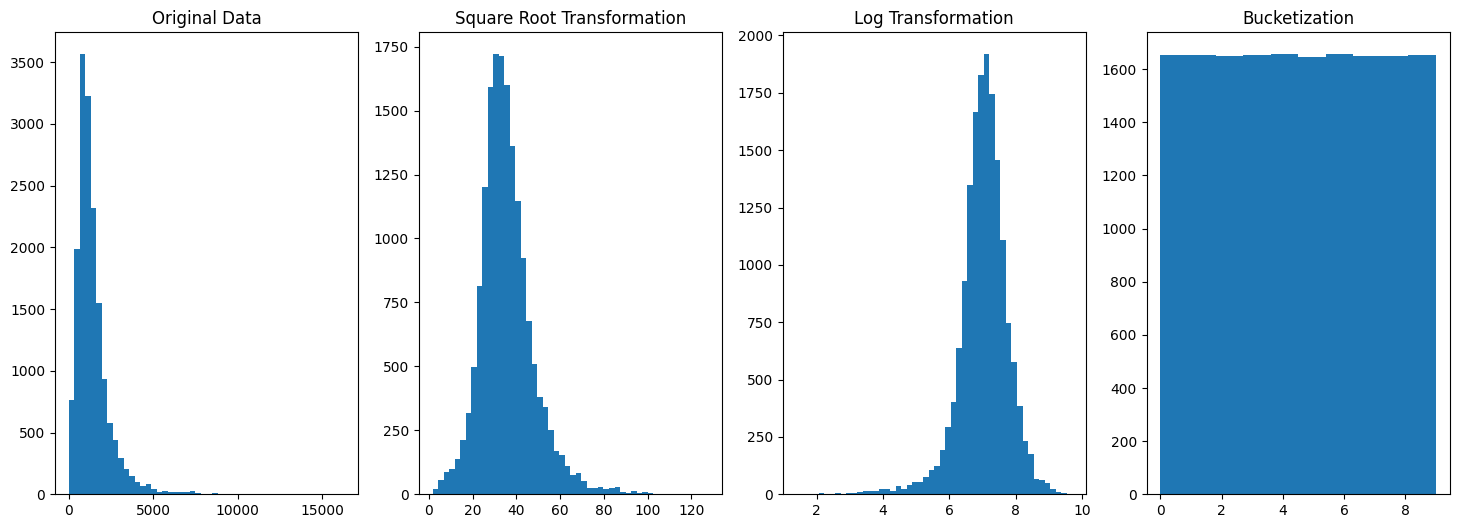

In [341]:
fig, ((ax1, ax2, ax3, ax4)) = plt.subplots(1, 4, figsize=(18, 6))

# histogramas antes da transformação
ax1.hist(housing_tr['population'], bins=50)
ax1.set_title('Original Data')

# square root transformation
housing_tr_sqrt = np.sqrt(housing_tr['population'])
ax2.hist(housing_tr_sqrt, bins=50)
ax2.set_title('Square Root Transformation')

# log transformation
housing_tr_log = np.log(housing_tr['population'] + 1) # adiciona 1 para evitar log(0)
ax3.hist(housing_tr_log, bins=50)
ax3.set_title('Log Transformation')

# Bucketization
housing_tr_bucketized = pd.qcut(housing_tr['population'], q=10, labels=False, duplicates='drop')
ax4.hist(housing_tr_bucketized, bins=10)
ax4.set_title('Bucketization')

plt.show()


Se utilizar distribuicoes multimodais de forma bruta em modelos que assumem um comportamente global monotonico (apenas cresce uma vez e depois diminui) ele tera um desempenho ruim pois nessas distribuicoes regios diferentes tem comportamentos diferentes e muitas vezes individuais... transformar essas distribuicoes pode ser util tanto para melhorar o modelo como para conseguir identificar padroes especificos de cada moda da distribuicao.

Se a distribuição é multimodal (mais de um pico de valores comuns), como a idade da casa. Uma forma é usar buckets dividindo os intervalos de valores (cut) e isso nos permite criar categorias com intervalos diferentes e podemos deixar os picos em categorias diferentes e depois usar um onehot para tornalos independentes...  assim voce vai conseguir que o modelo aprenda regras de faixas especificas dos valores.

Outra maneira de lidar com multimodais é usando Gaussian RBF (Radial Basis Function) que basicamente cria uma feature para cada pico/moda e para cada ponto calculamos a similiaridade/diferença do ponto para os picos (esse seria o valor dessas novas colunas) e portanto o valor da coluna similiaridade_pico1 de um ponto com o mesmo valor seria exatamente 1. Dessa forma, conseguimos dar peso para quanto estamos proximos de picos ou longe.

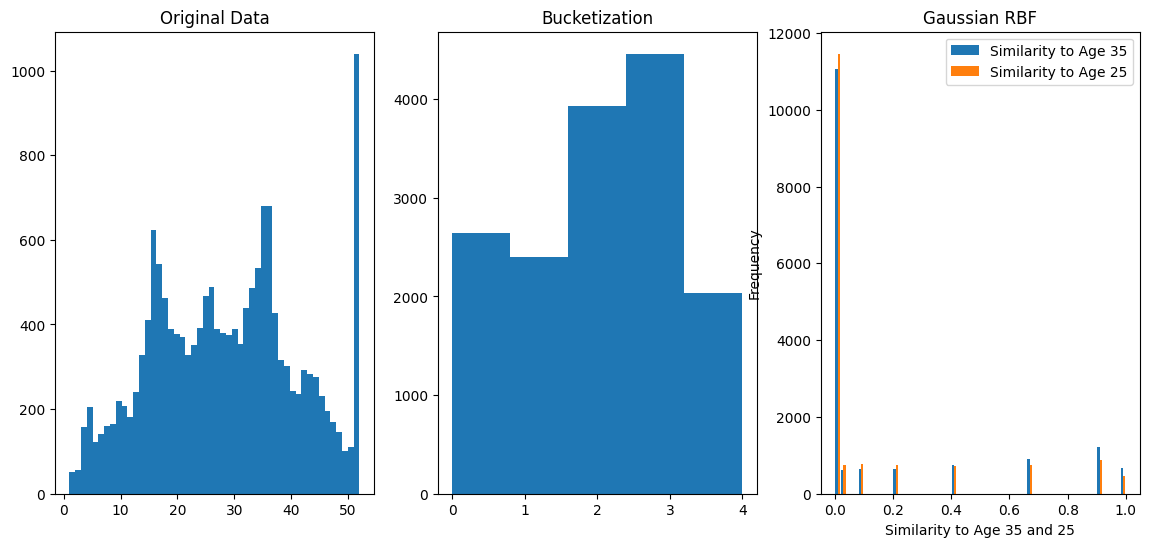

In [342]:
from sklearn.metrics.pairwise import rbf_kernel
subplots = plt.subplots(1,3,figsize=(14, 6)) # lidando com distribuções multimodais

# original data
subplots[1][0].hist(housing_tr['housing_median_age'], bins=50)
subplots[1][0].set_title('Original Data')

# bucket
housing_tr_bucketized = pd.cut(housing_tr['housing_median_age'], bins=[0, 15, 20, 30, 40, 50], labels=False)
subplots[1][1].hist(housing_tr_bucketized, bins=5)
subplots[1][1].set_title('Bucketization')

# distribuicao das features do Gaussian RBF comparada com a original
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35], [25]],
gamma=0.1)
subplots[1][2].hist(age_simil_35, bins=50)
subplots[1][2].set_title('Gaussian RBF')
subplots[1][2].set_xlabel('Similarity to Age 35 and 25')
subplots[1][2].set_ylabel('Frequency')
subplots[1][2].legend(['Similarity to Age 35', 'Similarity to Age 25'])

plt.show()


Transformação em targets/labels: Os labels/targets também podems seguir uma distribuicao de cauda pesada e podem precisar de transformacoes... nesses casos é importante ter nocao que agora o modelo faz predicao da variavel transformada e portanto precisamos destransformar ela para interpretar (inverso). Uma outra solucao é usar o TransformedTargetRegressor em que usamos de parametros o modelo e o scaler e usamos o objeto como se fosse um modelo.

In [343]:
# exemplo de inverse transform
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
target_scaler.fit(housing_labels.to_frame())
housing_labels_scaled = target_scaler.transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing_tr_standard, housing_labels_scaled)
predictions_scaled = model.predict(housing_tr_standard)
predictions = target_scaler.inverse_transform(predictions_scaled)

print(predictions_scaled[:5])
print(predictions[:5])

from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(regressor=LinearRegression(), transformer=StandardScaler())
model.fit(housing_tr_standard, housing_labels)
predictions = model.predict(housing_tr_standard)

print()
print("Predictions with TransformedTargetRegressor:")
print(predictions[:5])



[[ 0.60893178]
 [ 1.08289522]
 [-0.60048581]
 [-0.70464648]
 [ 0.82402732]]
[[276549.7809867 ]
 [331202.76827753]
 [137091.16571384]
 [125080.34119116]
 [301352.56666404]]

Predictions with TransformedTargetRegressor:
[276549.7809867  331202.76827753 137091.16571384 125080.34119116
 301352.56666404]


Podemos automatizar todas as alterações feitas anteriormente com um pipeline que concatena operações (Transformers, Scalers e ate modelos) e o objeto retornado mantem os métodos do ultimo estimador da lista... Além disso, pode ser um pouco chato ter que separar os dados categoricos e numéricos para fazer modificações neles e depois voltar tudo e para isso existe o ColumnTransformer que permite selecionarmos conjuntos de transformers ou pipelines e aplicarmos eles apenas a um subconjunto das features.

In [344]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

# feature_names_out recebe (transformer, input_names) e retorna os nomes das colunas de saída
def ratio_feature_names(transformer, input_names):
    return [f"{input_names[0]}_per_{input_names[1]}"]

ratio_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('ratio', FunctionTransformer(column_ratio, validate=True, feature_names_out=ratio_feature_names)),
    ('scaler', StandardScaler())
])

# log-pipeline para features numéricas com caudas pesadas
log_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='median')),
        ('log_transformer', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
        ('scaler', StandardScaler())
    ]
)

# pipeline para features categóricas
cat_pipeline = Pipeline(
    [
        ('frequentt_imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# pipeline padrão para features numéricas
num_pipeline = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessing = ColumnTransformer(
    [
        ('pop_ratio',      ratio_pipeline, ['population',    'households']),
        ('rooms_ratio',    ratio_pipeline, ['total_rooms',   'households']),
        ('bedrooms_ratio', ratio_pipeline, ['total_bedrooms','total_rooms']),
        ('log_pipeline', log_pipeline, ['population', 'total_rooms', 'total_bedrooms']),
        ('cat_pipeline', cat_pipeline, ['ocean_proximity'])
    ],
    remainder=num_pipeline # se nenhum pipeline for aplicado as colunas restantes serão dropadas
    # se usar a string 'passthrough', as colunas restantes serão passadas sem transformação 
    # se usar a string 'drop', as colunas restantes serão dropadas 
)


preprocessing.fit(housing)
housing_prepared = preprocessing.transform(housing)

print(housing_prepared.shape)
print(housing_prepared[:5])
print(preprocessing.get_feature_names_out())

housing_prepared_df = pd.DataFrame(housing_prepared, columns=preprocessing.get_feature_names_out(), index=housing.index)
housing_prepared_df.head()


(16512, 15)
[[-0.33020372 -0.86602737  1.84662439  0.45731294  0.63853808  1.33150164
   0.          0.          0.          1.          0.         -1.42303652
   1.0136059   1.86111875 -0.93649149]
 [-0.25361631  0.0245495  -0.5081207  -0.71371985 -0.06408519 -0.25592046
   1.          0.          0.          0.          0.          0.59639445
  -0.702103    0.90762971  1.17194198]
 [-0.05104091 -0.04119332 -0.20215476 -0.94440512 -0.86151    -0.93172887
   0.          1.          0.          0.          0.         -1.2030985
   1.27611874  0.35142777 -0.75978881]
 [-0.14147547 -0.03485833 -0.14900562  0.67164902  0.94466294  0.95741335
   0.          1.          0.          0.          0.          1.23121557
  -0.88492444 -0.91989094 -0.85028088]
 [-0.30614815 -0.66655412  0.96320807  0.72016691  1.00488661  1.44586957
   0.          0.          0.          0.          1.          0.71136206
  -0.87554898  0.58980003 -0.18036472]]
['pop_ratio__population_per_households'
 'rooms_ratio

,pop_ratio__population_per_households,rooms_ratio__total_rooms_per_households,bedrooms_ratio__total_bedrooms_per_total_rooms,log_pipeline__population,log_pipeline__total_rooms,log_pipeline__total_bedrooms,cat_pipeline__ocean_proximity_<1H OCEAN,cat_pipeline__ocean_proximity_INLAND,cat_pipeline__ocean_proximity_ISLAND,cat_pipeline__ocean_proximity_NEAR BAY,cat_pipeline__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age,remainder__median_income
13096,-0.330204,-0.866027,1.846624,0.457313,0.638538,1.331502,0.0,0.0,0.0,1.0,0.0,-1.423037,1.013606,1.861119,-0.936491
14973,-0.253616,0.024550,-0.508121,-0.713720,-0.064085,-0.255920,1.0,0.0,0.0,0.0,0.0,0.596394,-0.702103,0.907630,1.171942
3785,-0.051041,-0.041193,-0.202155,-0.944405,-0.861510,-0.931729,0.0,1.0,0.0,0.0,0.0,-1.203098,1.276119,0.351428,-0.759789
14689,-0.141475,-0.034858,-0.149006,0.671649,0.944663,0.957413,0.0,1.0,0.0,0.0,0.0,1.231216,-0.884924,-0.919891,-0.850281
20507,-0.306148,-0.666554,0.963208,0.720167,1.004887,1.445870,0.0,0.0,0.0,0.0,1.0,0.711362,-0.875549,0.589800,-0.180365


### Selecionando o modelo e treinando 

Agora que os dados estão tratados podemos começar a testar modelos e valida-los ... para isso precisamos de um conjunto de validação que não seja o teste (para não acontecer dataleakge, nem overffiting de parametros nem dada snoping). Podemos usar um train_test_split() para dividir nosso treino em trein e validação... mas caso nosso dataset não seja muito grande nem nossos modelos não sejam redes neurais gigantes que demoram para treinar podemos usar cross-validation para ter uma distribuição de métricas e consequentemente menor chance do modelo ser bom ao acaso...

In [345]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error


linear = Pipeline([
    ('preprocessing', preprocessing),
    ('regressor', LinearRegression())
])  

decision = Pipeline([
    ('preprocessing', preprocessing),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

random_forest = Pipeline([
    ('preprocessing', preprocessing),
    ('regressor', RandomForestRegressor(random_state=42))
]) # o parametro memory é usado para armazenar os resultados intermediários do pipeline, o que pode acelerar o processo de treinamento e previsão.
# porém só funciona em .py

linear.fit(housing, housing_labels)
decision.fit(housing, housing_labels)
random_forest.fit(housing, housing_labels)

linear_predictions = linear.predict(housing)
decision_predictions = decision.predict(housing)
random_forest_predictions = random_forest.predict(housing)

print("Linear Regression RMSE:", root_mean_squared_error(housing_labels, linear_predictions))
print("Decision Tree RMSE:", root_mean_squared_error(housing_labels, decision_predictions))
print("Random Forest RMSE:", root_mean_squared_error(housing_labels, random_forest_predictions))





Linear Regression RMSE: 66576.49228692107
Decision Tree RMSE: 0.0
Random Forest RMSE: 18479.025398054957


Aqui não dividimos em treino e validação e portanto temos coisas como um 0 em erros... isso é uma caracterisca intriseca de Decision Trees em que eles podem se adaptar perfeitamente aos dados e da solução exata... porém todos os modelos estão com overfittig e seria necessário uma validação para ver isso. Podemos usar um cross_validation score para avaliar o modelo com maior confiança.

In [346]:
from sklearn.model_selection import cross_val_score

linear_scores = cross_val_score(linear, housing, housing_labels, scoring='neg_root_mean_squared_error', cv=5)
decision_scores = cross_val_score(decision, housing, housing_labels, scoring='neg_root_mean_squared_error', cv=5)
random_forest_scores = cross_val_score(random_forest, housing, housing_labels, scoring='neg_root_mean_squared_error', cv=5)

print("Linear Regression CV RMSE:", -linear_scores)
print("Decision Tree CV RMSE:", -decision_scores)
print("Random Forest CV RMSE:", -random_forest_scores)

print("Linear Regression CV: \n", -pd.Series(linear_scores).describe())
print("Decision Tree CV: \n", -pd.Series(decision_scores).describe())
print("Random Forest CV: \n", -pd.Series(random_forest_scores).describe())


Linear Regression CV RMSE: [68043.33023042 66910.39391405 67467.94522526 66379.0128324
 66238.94431255]
Decision Tree CV RMSE: [66973.21337176 73847.05583878 70911.4946757  72264.10449628
 70651.08804552]
Random Forest CV RMSE: [49614.06326844 49229.72976427 50054.76838558 51114.69329742
 50111.96091999]
Linear Regression CV: 
 count       -5.000000
mean     67007.925303
std       -754.992835
min      68043.330230
25%      67467.945225
50%      66910.393914
75%      66379.012832
max      66238.944313
dtype: float64
Decision Tree CV: 
 count       -5.000000
mean     70929.391286
std      -2550.653959
min      73847.055839
25%      72264.104496
50%      70911.494676
75%      70651.088046
max      66973.213372
dtype: float64
Random Forest CV: 
 count       -5.000000
mean     50025.043127
std       -706.612266
min      51114.693297
25%      50111.960920
50%      50054.768386
75%      49614.063268
max      49229.729764
dtype: float64


### Melhorando os modelos com hyperparametros

Imagine que temos um bom modelo e precisamos otimizar os hiperparâmetros... podemos testar infinitas possibilidades mas isso seria um processo chato e demorado... para isso existem objetos de busca como GridSearch, RandomSearch e suas variações Halving.

- GridSearch: Aqui definimos um dicionáiro de listas de valores de hiperparametros que queremos testar e todas as combinacoes de cada dicionário serao testadas usando cross-validation.

- RandomSearch: Aqui definimos um dicionário de listas de distribuicoes de probabilidade que tem minimo e máximo definidos no range em que quer testar e temos o numero de iteracoes em que cada iteracao é uma amostragem aleatoria na distribuicoes dos hiperparametros e em cada iteracao usamos cross-validation. Random tem certas vantagens quando o range [min,max] dos hiperparametros é muito grandes cada uma das n iteracoes vamos testar valores diferentes e oq no grid teriamos que escolher valores especificos... Nesses casos fazer varias iteracoes aleatórias é mais interessante pois testamos mais valores (cobre melhor o espaço de busca).

- HalvingRandomSearchCV e HalvingGridSearchCV: Nesses dois métodos experimentais economizamos recursos de treinamento fazendo o seguinte... primeiro treinamos todas as combinacoes/amostragens com 10% dos dados de treino e avaliamos, discartamos a metade pior e fazemos o mesmo procedimento ate sobrar poucos candidatos que serao treinados com o dataset inteiro. Muito util se tiver tempo ou recursos limitados mas corre o risco de eliminar bons modelos prematuramente que demoram mais para melhorar muito.

In [347]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
    'regressor__n_estimators': [50, 100], # __ é usado para acessar os hiperparâmetros do regressor dentro do pipeline 
    'regressor__max_depth': [None, 10, 20], # Se quisermos acessar valores dentro do pipeline preprocessing seria algo como 'preprocessing__pop_ratio__ratio__column_ratio__feature_names_out' 
     # para acessar os nomes das colunas de saída do pipeline de ratio, por exemplo.
    },
    {
    'regressor__n_estimators': [200, 300],
    'regressor__max_depth': [None, 30],
    'regressor__min_samples_split': [2, 5],
    }
]

# aqui vamos testar 2*3 = 6 combinacoes para o primeiro conjunto de hiperparâmetros e 2*2*2 = 8 combinacoes para o segundo conjunto, totalizando 14 combinacoes. 
# Cada combinação será avaliada usando validação cruzada de 2 folds, o que significa que cada combinação será treinada e avaliada 2 vezes, totalizando 14*2 = 28 treinamentos e avaliações.

grid_search = GridSearchCV(random_forest, param_grid, scoring='neg_root_mean_squared_error', cv=2, n_jobs=-1)
grid_search.fit(housing, housing_labels)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.head()


Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Best CV RMSE: 51598.27343451874


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__max_depth,param_regressor__n_estimators,param_regressor__min_samples_split,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,3.693195,0.005083,0.097211,0.010002,None,50,NaN,"{'regressor__max_depth': None, 'regressor__n_e...",-51118.856728,-53192.443452,-52155.650090,1036.793362,11
1,7.413382,0.027986,0.228960,0.020326,None,100,NaN,"{'regressor__max_depth': None, 'regressor__n_e...",-50853.196674,-52908.142901,-51880.669788,1027.473113,10
2,2.350581,0.022291,0.049771,0.001616,10,50,NaN,"{'regressor__max_depth': 10, 'regressor__n_est...",-52948.708009,-54853.101114,-53900.904561,952.196552,14
3,4.671233,0.009270,0.126134,0.045316,10,100,NaN,"{'regressor__max_depth': 10, 'regressor__n_est...",-52815.319684,-54618.396668,-53716.858176,901.538492,13
4,3.512935,0.006919,0.089646,0.007007,20,50,NaN,"{'regressor__max_depth': 20, 'regressor__n_est...",-51231.989884,-53212.143636,-52222.066760,990.076876,12


In [348]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'regressor__n_estimators': randint(50, 300), # aqui estamos usando uma distribuição uniforme discreta para escolher o número de estimadores entre 50 e 300
    'regressor__max_depth': randint(10, 50), # aqui estamos usando uma distribuição uniforme discreta para escolher a profundidade máxima entre 10 e 50
}


# n_iter é o número de combinações aleatórias a serem testadas, nesse caso, vamos testar 10 combinações aleatórias dos hiperparâmetros definidos em param_dist.
# teriamos entao 10 treinamentos e cada treinamento seria avaliado usando validação cruzada de 2 folds, totalizando 10*2 = 20 treinamentos e avaliações.

random_search = RandomizedSearchCV(random_forest, param_dist, n_iter=10, scoring='neg_root_mean_squared_error', cv=2, n_jobs=-1, random_state=42)
random_search.fit(housing, housing_labels)

print("Best Parameters:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)
cv_res_random = pd.DataFrame(random_search.cv_results_)
cv_res_random.head()

Best Parameters: {'regressor__max_depth': 28, 'regressor__n_estimators': 264}
Best CV RMSE: 51641.84250461058


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__max_depth,param_regressor__n_estimators,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,15.660617,0.007497,0.342324,0.006074,48,229,"{'regressor__max_depth': 48, 'regressor__n_est...",-50737.385456,-52586.617741,-51662.001598,924.616143,3
1,4.415654,0.016744,0.105629,0.002913,38,64,"{'regressor__max_depth': 38, 'regressor__n_est...",-51039.471787,-53065.954776,-52052.713281,1013.241495,10
2,14.917398,0.017516,0.292907,0.000558,17,238,"{'regressor__max_depth': 17, 'regressor__n_est...",-50809.931872,-52655.033506,-51732.482689,922.550817,5
3,10.609749,0.011549,0.227563,0.000960,30,152,"{'regressor__max_depth': 30, 'regressor__n_est...",-50851.008422,-52700.309113,-51775.658768,924.650346,8
4,17.817768,0.126432,0.332720,0.004734,28,264,"{'regressor__max_depth': 28, 'regressor__n_est...",-50750.797544,-52532.887465,-51641.842505,891.044961,1


In [349]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV


halving_random_search = HalvingRandomSearchCV(random_forest, param_dist, scoring='neg_root_mean_squared_error', cv=2, n_jobs=-1, random_state=42, factor=3,  aggressive_elimination=True)
halving_random_search.fit(housing, housing_labels)

print("Best Parameters:", halving_random_search.best_params_)
print("Best CV RMSE:", -halving_random_search.best_score_)
cv_res_halving_random = pd.DataFrame(halving_random_search.cv_results_)
cv_res_halving_random.head()

Best Parameters: {'regressor__max_depth': 27, 'regressor__n_estimators': 54}
Best CV RMSE: 54037.95607150483


,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__max_depth,param_regressor__n_estimators,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,mean_train_score,std_train_score
0,0,4,0.254170,0.000596,0.028855,0.000059,48,229,"{'regressor__max_depth': 48, 'regressor__n_est...",-49731.604945,-13697.309420,-31714.457182,18017.147762,2775,-6592.354206,-24623.615513,-15607.984860,9015.630653
1,0,4,0.093500,0.000092,0.017254,0.000122,38,64,"{'regressor__max_depth': 38, 'regressor__n_est...",-49412.456347,-11210.636102,-30311.546225,19100.910123,234,-6155.968922,-22993.638859,-14574.803891,8418.834968
2,0,4,0.271929,0.006603,0.029712,0.000139,17,238,"{'regressor__max_depth': 17, 'regressor__n_est...",-49791.959435,-13842.339205,-31817.149320,17974.810115,3218,-6669.583161,-24912.079396,-15790.831278,9121.248117
3,0,4,0.184111,0.001684,0.023427,0.000157,30,152,"{'regressor__max_depth': 30, 'regressor__n_est...",-50024.317107,-13201.074060,-31612.695583,18411.621523,1707,-6463.646610,-24142.869747,-15303.258178,8839.611569
4,0,4,0.294927,0.001283,0.033857,0.000022,28,264,"{'regressor__max_depth': 28, 'regressor__n_est...",-49867.945146,-14111.352152,-31989.648649,17878.296497,3790,-6477.440150,-24194.391076,-15335.915613,8858.475463


### Analisando o melhor modelo, features e erro no conjunto de teste

In [350]:
final_model = random_search.best_estimator_
feature_importances = final_model.named_steps['regressor'].feature_importances_

sorted(zip(preprocessing.get_feature_names_out(), feature_importances), key=lambda x: x[1], reverse=True)

[('remainder__median_income', np.float64(0.4748668402187099)),
 ('cat_pipeline__ocean_proximity_INLAND', np.float64(0.14009850049408507)),
 ('pop_ratio__population_per_households', np.float64(0.123735296998505)),
 ('remainder__longitude', np.float64(0.05960166473514797)),
 ('remainder__latitude', np.float64(0.0566763191437309)),
 ('remainder__housing_median_age', np.float64(0.04426107962453302)),
 ('rooms_ratio__total_rooms_per_households', np.float64(0.027736848670664647)),
 ('bedrooms_ratio__total_bedrooms_per_total_rooms',
  np.float64(0.023533436372332413)),
 ('log_pipeline__total_rooms', np.float64(0.015634917160950775)),
 ('log_pipeline__total_bedrooms', np.float64(0.01460714559638606)),
 ('log_pipeline__population', np.float64(0.014569568640689234)),
 ('cat_pipeline__ocean_proximity_NEAR OCEAN',
  np.float64(0.002649348451698752)),
 ('cat_pipeline__ocean_proximity_<1H OCEAN',
  np.float64(0.0011967233953913228)),
 ('cat_pipeline__ocean_proximity_NEAR BAY', np.float64(0.000726622

Analisando as importancias é possivel ver quais features o modelo considerou mais importante para predição... nesse momento em que testamos a justiça do modelo com todos os clusteres/grupos da amostra. O modelo não tem que apenas se sair bem na media mas também em grupos especificos isolados. Isso se chama bias analyses em que criamos varios subgrupos de validação em que cada um deles representa um grupo e depois testamos o modelo neles. Se ele for mal em um desses grupos então é necessário analisar os motivos e não fazer deploy do modelo ou pelo menos não fazer predição daquele grupo.

In [351]:
X_test = strat_test_set.drop('median_house_value', axis=1)
y_test = strat_test_set['median_house_value'].copy()

final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print("Final RMSE on Test Set:", final_rmse)


Final RMSE on Test Set: 50221.70323234983


Se voce tunar exageradamente os hiperparametros no conjunto de validação é bem provavel que o desempenho no conjunto de teste seja ligeiramente pior pois estamos meio que ajustando o modelo para dados de validação... Além disso, muitas vezes um numero apenas não é suficiente então podemos gerar um intervalo de confiança da métrica nos dados de teste com bootstrap ou parametricamente.

In [352]:
confidence = 0.95

# parametrico 

n = len(y_test)
m = final_rmse
std_error = m / np.sqrt(n)
interval = (m - 1.96 * std_error, m + 1.96 * std_error)
print(f"Parametric 95% confidence interval for the true RMSE: {interval}")

# bootstrap
from scipy.stats import bootstrap
def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

squared_errors = (y_test - final_predictions) ** 2
res = bootstrap((squared_errors,), rmse, confidence_level=confidence, n_resamples=1000, method='percentile', random_state=42)
print(f"Bootstrap 95% confidence interval for the true RMSE: {res.confidence_interval}")

Parametric 95% confidence interval for the true RMSE: (np.float64(48689.636562982676), np.float64(51753.76990171698))
Bootstrap 95% confidence interval for the true RMSE: ConfidenceInterval(low=np.float64(47863.163201121504), high=np.float64(52602.85585597568))


### Launch, Monitor, and Maintain Your System

Uma vez que o modelo esta aprovado podemos fazer deploy dele e para isso precisamos salvar o modelo em algum formato e manda-lo para produção e la na produção o modelo devera ser carregado (idealmente o modelo é carregado apenas uma vez para reduzir latencia) e usado para responder requisições... o modelo poderia ficar no mesmo servidor  da aplicação que irá utiliza-lo ? sim mas sempre que precisarmos mudar o modelo, atualizar o modelo ou até mesmo conserta-lo teriamos que parar a aplicação inteira... é uma melhor ideia manter o modelo em um servidor isolado (como um serviço da google cloud) que conversará através de uma interface (predições, recomendações...) por exemplo de predict. Além disso, o modelo não deve apenas ser colocado em produção, ele deve ser monitorado constantemente para por algum motivo sua performace caiu mais que algum limite (seja por erro, problemas ou os dados estão ficando velhos)... e caso ele de problema é importante ter um backup de modelo para rapidamente trocar ou até mesmo comparar os modelos antigos e novos. Outro ponto são os dados que alimentam periodicamente o modelo... se esses dados forem ruins o modelo ira degradar lentamente e talz o monitoramento não pegue isso cedo... portanto também é interessante monitorar e tratar os dados novos que chegam verificando se tem um deslocamento muito grande no desvio padrão e media ou se o numero de missing e outliers aumentou e até mesmo versionar eles caso algum dos bancos seja corrompido... O monitoramente geralmente usa alguma métrica de qualidade do modelo ou de business como por exemplo um sistema de recomendação pode usar de métrica o numero de itens recomendados que são de fato vendidos.

Conforme os dados evoluem é eficiente automatizar essas etapas de coleta, treino e validação. A coleta pode ser feita constantemente e usar pessoas para rotular os dados. O treino pode ser automatico de tempos em tempos (dias, semanas) e o deploy acontecer caso o novo modelo seja validado em conjuntos que medem erro e justiça.

In [353]:
import cloudpickle
# poderia usar o joblib, mas ele tem problemas para serializar funções definidas no notebook, 
# enquanto o cloudpickle é capaz de lidar com isso.

with open('final_model.pkl', 'wb') as f:
    cloudpickle.dump(final_model, f)  # cloudpickle serializa funções definidas no notebook

with open('final_model.pkl', 'rb') as f:
    loaded_model = cloudpickle.load(f)

loaded_predictions = loaded_model.predict(X_test)
loaded_rmse = root_mean_squared_error(y_test, loaded_predictions)
print("RMSE of loaded model on Test Set:", loaded_rmse)


RMSE of loaded model on Test Set: 50221.70323234983
